# Assignment 1: Word Embeddings, Sentiments and Topics
**Course:** Large Language Models for Marketing (FEM11154)  
**Dataset:** Meta Ray-Ban Smart Glasses — Amazon Reviews

---

## Step 1: Data Loading & Preprocessing

Before any analysis, we need to:
1. Load the CSV
2. Remove reviews that are empty or too short to be useful
3. Clean the text (strip HTML, lowercase, remove punctuation/stopwords)
4. Filter out non-English reviews
5. Inspect the final dataset

In [6]:
# Install required libraries (uncomment if running on Google Colab)
!pip install pandas nltk langdetect gensim
# test github

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.4 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=fac79eea31da79e48e8497a330c2c3472da06cf5846fb0e81d0f8fe2f4a6bbc1
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
import pandas as pd
import re
import nltk

# Download NLTK resources we need for tokenisation and stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ── Load data ──────────────────────────────────────────────────────────────────
# df = pd.read_csv('data/Meta-Glasses-Reviews.csv')
df = pd.read_csv('/content/Meta-Glasses-Reviews.csv')

print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Rows loaded: 10000
Columns: ['reviewID', 'name', 'date', 'verifiedPurchase', 'rating', 'helpful', 'title', 'review', 'profile', 'country', 'reviewLink', 'reviewImage', 'helpful_aug', 'is_positive_review', 'helpfulness_score']


,reviewID,name,date,verifiedPurchase,rating,helpful,title,review,profile,country,reviewLink,reviewImage,helpful_aug,is_positive_review,helpfulness_score
0,R26GJW65W9X4OB,HebeZ,"March 9, 2025",True,4.0,12,Solid Smart Glasses with Room for Improvement,The Ray-Ban Meta Glasses in the classic Wayfar...,https://www.amazon.com/gp/profile/amzn1.accoun...,United States,https://www.amazon.com/gp/customer-reviews/R26...,NaN,15,1,6.048932
1,R1LPZH3QJAOVAI,Karla silva,"December 4, 2025",True,5.0,NaN,Excelentes a mi esposo le encantan,Excelentes a mi esposo le encantan,https://www.amazon.com/gp/profile/amzn1.accoun...,United States,https://www.amazon.com/gp/customer-reviews/R1L...,NaN,2,1,5.397819
2,R1ASIRA3BE7065,Trinison12,"November 12, 2025",True,5.0,NaN,Now you see me,"I purchased these for my fiancé, for our anniv...",https://www.amazon.com/gp/profile/amzn1.accoun...,United States,https://www.amazon.com/gp/customer-reviews/R1A...,NaN,0,1,4.486596


In [3]:
# ── Quick look at the DV (rating) ─────────────────────────────────────────────
print('Rating distribution:')
print(df['rating'].value_counts().sort_index())
print(f"\nMissing ratings: {df['rating'].isna().sum()}")

Rating distribution:
rating
1.0     294
3.0    1423
4.0    3380
5.0    4903
Name: count, dtype: int64

Missing ratings: 0


In [4]:
# ── Step 1a: Drop rows with empty or very short reviews ───────────────────────
# We need actual text to analyse — reviews under 15 words are too short
# to be meaningful for embeddings or topic modelling.

df['review'] = df['review'].fillna('')           # treat NaN as empty string
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

before = len(df)
df = df[df['word_count'] >= 15].copy()
print(f'Removed {before - len(df)} rows (empty or < 15 words). Remaining: {len(df)}')

Removed 2285 rows (empty or < 15 words). Remaining: 7715


In [7]:
# ── Step 1b: Filter non-English reviews ───────────────────────────────────────
# langdetect guesses the language of each review.
# We keep only English ones to ensure consistent NLP processing.

from langdetect import detect, LangDetectException

def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

print('Detecting languages (this may take ~30 seconds)...')
df['is_english'] = df['review'].apply(is_english)

before = len(df)
df = df[df['is_english']].copy()
print(f'Removed {before - len(df)} non-English reviews. Remaining: {len(df)}')

Detecting languages (this may take ~30 seconds)...
Removed 0 non-English reviews. Remaining: 7715


In [8]:
# ── Step 1c: Clean the raw text ───────────────────────────────────────────────
# We do two versions:
#   - review_clean : readable text, used for BERTopic and sentiment analysis
#   - review_tokens: list of lowercase words, used for Word2Vec training

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    """Remove HTML tags, URLs, and extra whitespace. Keep punctuation for readability."""
    text = str(text) if text is not None else ''  # handle NaN/float values
    text = re.sub(r'<.*?>', ' ', text)          # strip HTML tags like <br>
    text = re.sub(r'http\S+', '', text)          # strip URLs
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    return text

def tokenize(text):
    """Lowercase, remove punctuation and stopwords, return list of words."""
    text = clean_text(text)
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
    return tokens

df['review_clean']  = df['review'].apply(clean_text)
df['review_tokens'] = df['review'].apply(tokenize)

# Preview
print('Original review:')
print(df['review'].iloc[0][:300])
print('\nCleaned:')
print(df['review_clean'].iloc[0][:300])
print('\nTokenised (first 20 tokens):')
print(df['review_tokens'].iloc[0][:20])

Original review:
The Ray-Ban Meta Glasses in the classic Wayfarer style are an impressive step forward in smart eyewear. The design stays true to the iconic Ray-Ban look, making them stylish and easy to wear daily. The built-in camera and speakers provide a seamless hands-free experience for capturing moments and ta

Cleaned:
The Ray-Ban Meta Glasses in the classic Wayfarer style are an impressive step forward in smart eyewear. The design stays true to the iconic Ray-Ban look, making them stylish and easy to wear daily. The built-in camera and speakers provide a seamless hands-free experience for capturing moments and ta

Tokenised (first 20 tokens):
['meta', 'glasses', 'classic', 'wayfarer', 'style', 'impressive', 'step', 'forward', 'smart', 'eyewear', 'design', 'stays', 'true', 'iconic', 'look', 'making', 'stylish', 'easy', 'wear', 'daily']


Final dataset size: 7715 reviews
Average word count: 169.5 words

Rating distribution after cleaning:
rating
1.0     294
3.0    1423
4.0    2263
5.0    3735
Name: count, dtype: int64


FileNotFoundError: [Errno 2] No such file or directory: 'plots/01_data_overview.png'

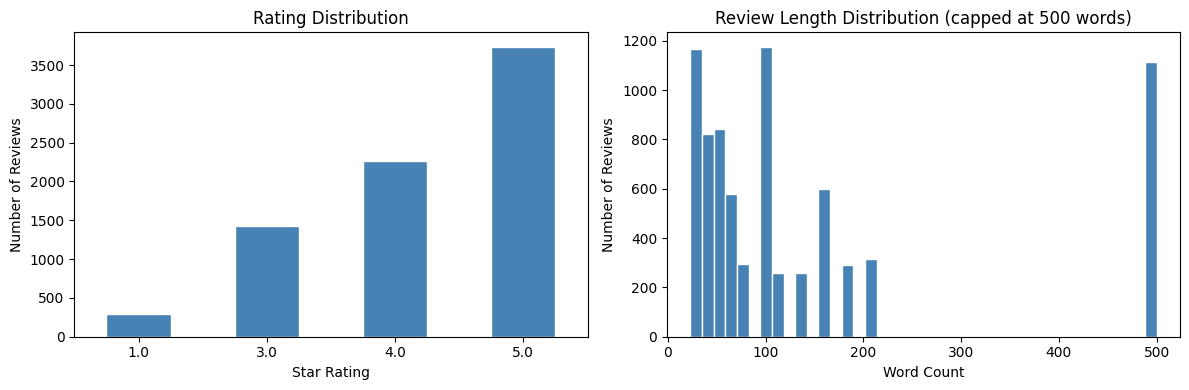

In [9]:
# ── Step 1d: Final dataset summary ────────────────────────────────────────────
import matplotlib.pyplot as plt

print(f'Final dataset size: {len(df)} reviews')
print(f"Average word count: {df['word_count'].mean():.1f} words")
print(f"\nRating distribution after cleaning:")
print(df['rating'].value_counts().sort_index())

# Plot rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)

df['word_count'].clip(upper=500).plot(kind='hist', bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Review Length Distribution (capped at 500 words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
# plt.savefig('plots/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/01_data_overview.png')

## Step 2: Word Embeddings

We train a Word2Vec model on the cleaned, tokenized reviews, then explore the embedding space to understand how the model represents product-related concepts.

In [10]:
# ── Step 2a: Train Word2Vec ────────────────────────────────────────────────────
# Word2Vec learns a 50-dimensional vector for each word by predicting
# neighbouring words in a sentence (Skip-Gram with window=5).
# min_count=3 drops words that appear fewer than 3 times (too rare to learn from).

from gensim.models import Word2Vec

sentences = df['review_tokens'].tolist()

model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # embedding dimension d=50
    window=5,         # context window on each side
    min_count=3,      # ignore words seen fewer than 3 times
    workers=4,        # parallel training threads
    seed=42
)

vocab_size = len(model.wv)
print(f'Vocabulary size: {vocab_size} words')
print(f'Embedding shape: {model.wv.vectors.shape}')
print(f'\nSample vector for "camera" (first 10 dims):')
print(model.wv['camera'][:10])

Vocabulary size: 1016 words
Embedding shape: (1016, 50)

Sample vector for "camera" (first 10 dims):
[ 1.5623057   1.8193947  -0.2980089   2.3323877   1.4270765  -3.2461464
  1.0051551  -0.99824315 -1.1017593  -2.7434697 ]


In [11]:
# ── Step 2b: Quality axis ("excellent" → "horrible") ─────────────────────────
# A "direction" in embedding space is just the vector difference between
# two opposite words. Words that project highly onto this axis share
# meaning with the positive end; low projections share meaning with the negative end.

import numpy as np

pos_word, neg_word = 'excellent', 'horrible'
quality_axis = model.wv[pos_word] - model.wv[neg_word]  # direction vector

# Project every word onto this axis
words = list(model.wv.index_to_key)
projections = {w: np.dot(model.wv[w], quality_axis) for w in words}

ranked = sorted(projections.items(), key=lambda x: x[1], reverse=True)

print(f'Quality axis: "{pos_word}" → "{neg_word}"\n')
print('Top 15 words (most positive / high quality):')
for w, score in ranked[:15]:
    print(f'  {w:20s} {score:+.3f}')

print('\nBottom 15 words (most negative / low quality):')
for w, score in ranked[-15:]:
    print(f'  {w:20s} {score:+.3f}')

Quality axis: "excellent" → "horrible"

Top 15 words (most positive / high quality):
  excellent            +276.890
  easy                 +171.320
  pair                 +150.593
  smart                +141.930
  super                +114.964
  like                 +113.141
  well                 +111.404
  color                +105.710
  microphone           +100.056
  look                 +99.653
  record               +96.649
  good                 +96.600
  size                 +94.169
  beautiful            +93.855
  design               +93.084

Bottom 15 words (most negative / low quality):
  fixed                -77.892
  vpn                  -78.364
  life                 -80.760
  respond              -82.192
  snap                 -82.845
  future               -83.281
  think                -86.513
  supposed             -87.095
  occasional           -88.111
  done                 -88.313
  horrible             -91.411
  happened             -91.738
  short              

In [12]:
# ── Step 2c: Inspect one embedding dimension ──────────────────────────────────
# Each of the 50 dimensions is a learned feature. We can look at which words
# score highest/lowest on a single dimension to get a sense of what it captures.

DIM = 0  # change this to inspect other dimensions (0–49)

dim_scores = {w: model.wv[w][DIM] for w in words}
dim_ranked = sorted(dim_scores.items(), key=lambda x: x[1], reverse=True)

print(f'Dimension #{DIM}\n')
print('Highest-scoring words:')
for w, score in dim_ranked[:10]:
    print(f'  {w:20s} {score:+.4f}')

print('\nLowest-scoring words:')
for w, score in dim_ranked[-10:]:
    print(f'  {w:20s} {score:+.4f}')

Dimension #0

Highest-scoring words:
  limited              +5.5613
  photos               +4.9054
  good                 +4.3591
  use                  +4.0825
  better               +4.0613
  assistant            +3.8405
  focus                +3.8010
  even                 +3.7504
  apps                 +3.5962
  wifi                 +3.5496

Lowest-scoring words:
  look                 -3.4306
  made                 -3.4515
  youtube              -3.5297
  size                 -3.6060
  head                 -3.6321
  loves                -3.7139
  accessory            -3.9740
  buy                  -4.1587
  regret               -4.3229
  getting              -4.9529


In [13]:
# ── Step 2d: Analysis i — Nearest neighbours of brand-related words ───────────
# Words that are close in embedding space tend to appear in similar contexts.
# For brand words, this reveals what reviewers associate with each concept.

brand_words = ['meta', 'rayban', 'camera', 'audio', 'glasses']

for word in brand_words:
    if word in model.wv:
        neighbors = model.wv.most_similar(word, topn=8)
        print(f'\nNearest neighbours of "{word}":')
        for neighbor, similarity in neighbors:
            print(f'  {neighbor:20s} cosine similarity: {similarity:.3f}')
    else:
        print(f'\n"{word}" not in vocabulary (too rare or filtered out)')


Nearest neighbours of "meta":
  phone                cosine similarity: 0.455
  answers              cosine similarity: 0.410
  questions            cosine similarity: 0.379
  button               cosine similarity: 0.378
  translates           cosine similarity: 0.369
  videos               cosine similarity: 0.364
  hey                  cosine similarity: 0.356
  rest                 cosine similarity: 0.354

Nearest neighbours of "rayban":
  leaving              cosine similarity: 0.788
  ashamed              cosine similarity: 0.738
  lending              cosine similarity: 0.676
  vacation             cosine similarity: 0.560
  often                cosine similarity: 0.530
  tout                 cosine similarity: 0.492
  name                 cosine similarity: 0.488
  want                 cosine similarity: 0.472

Nearest neighbours of "camera":
  answering            cosine similarity: 0.472
  text                 cosine similarity: 0.468
  even                 cosine similarit

In [14]:
# ── Step 2e: Analysis ii — Word analogies ─────────────────────────────────────
# Word2Vec captures analogical relationships via vector arithmetic.
# "camera – photo + audio = ?" asks: what is to audio what "camera" is to "photo"?
# We add the positive words and subtract the negative word, then find the nearest result.

analogies = [
    # (positive words, negative words, interpretation)
    (['camera', 'audio'], ['photo'],  '"camera – photo + audio" → audio equivalent of a camera'),
    (['sound', 'bad'],    ['good'],   '"sound – good + bad"     → bad version of sound'),
    (['meta', 'glasses'], ['rayban'], '"meta – rayban + glasses" → what meta glasses are like without the brand'),
]

for positives, negatives, label in analogies:
    # Check all words exist in vocab before querying
    all_words = positives + negatives
    missing = [w for w in all_words if w not in model.wv]
    if missing:
        print(f'\n{label}')
        print(f'  Skipped — not in vocabulary: {missing}')
        continue
    results = model.wv.most_similar(positive=positives, negative=negatives, topn=5)
    print(f'\n{label}')
    for word, score in results:
        print(f'  {word:20s} {score:.3f}')


"camera – photo + audio" → audio equivalent of a camera
  voice                0.412
  sound                0.391
  includes             0.380
  ai                   0.380
  assistant            0.376

"sound – good + bad"     → bad version of sound
  major                0.568
  mode                 0.567
  two                  0.535
  portrait             0.522
  software             0.509

"meta – rayban + glasses" → what meta glasses are like without the brand
  push                 0.361
  quick                0.356
  awesome              0.350
  battery              0.344
  able                 0.322


## Step 3: Topic Modelling + Sentiment Analysis

We split each review into sentences, run BERTopic to discover recurring themes, then use VADER sentiment analysis to score each sentence. Finally, we compare topic prevalence and sentiment between low-rated (1–3★) and high-rated (4–5★) reviews.

In [16]:
# Install Step 3 dependencies (uncomment if needed)
!pip install bertopic sentence-transformers vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.0 MB/s eta 0:00:00


In [17]:
# ── Step 3a: Split reviews into sentences ─────────────────────────────────────
# BERTopic works best on short, focused text — sentences rather than full reviews.
# We keep each sentence's metadata (review_id, rating, star_group) for later aggregation.

from nltk.tokenize import sent_tokenize

df['star_group'] = df['rating'].apply(lambda r: 'low (1-3★)' if r <= 3 else 'high (4-5★)')

sentences_data = []
for idx, row in df.iterrows():
    for sent in sent_tokenize(row['review_clean']):
        if len(sent.split()) >= 5:   # skip fragments
            sentences_data.append({
                'review_id': idx,
                'rating':    row['rating'],
                'star_group': row['star_group'],
                'sentence':  sent
            })

sdf = pd.DataFrame(sentences_data)
print(f'Total sentences: {len(sdf)}')
print(f'\nSample:')
print(sdf['sentence'].head(3).tolist())

Total sentences: 70115

Sample:
['The Ray-Ban Meta Glasses in the classic Wayfarer style are an impressive step forward in smart eyewear.', 'The design stays true to the iconic Ray-Ban look, making them stylish and easy to wear daily.', 'The built-in camera and speakers provide a seamless hands-free experience for capturing moments and taking calls without pulling out your phone.']


In [18]:
# ── Step 3b: Run BERTopic ──────────────────────────────────────────────────────
# BERTopic embeds sentences with a transformer, clusters them with HDBSCAN,
# and labels each cluster with the most representative words.
#
# Strategy: fit on a 15k random sample (fast), then predict on all sentences.
# This gives the same topic definitions without the cost of embedding 70k sentences twice.
#
# ⏱ Expect ~5–10 minutes on CPU.

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

sample = sdf.sample(n=15000, random_state=42)

topic_model = BERTopic(
    embedding_model=embedding_model,
    nr_topics=12,        # reduce to ~12 coherent topics
    min_topic_size=80,   # ignore very small clusters
    verbose=True
)
topic_model.fit(sample['sentence'].tolist())

# Predict topics for all sentences
topics, _ = topic_model.transform(sdf['sentence'].tolist())
sdf['topic'] = topics

# Show discovered topics
topic_info = topic_model.get_topic_info()
print('\nDiscovered topics:')
for _, row in topic_info.iterrows():
    top_words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outlier sentences)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(top_words)}")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

2026-03-26 10:06:41,115 - BERTopic - Embedding - Completed ✓
2026-03-26 10:06:41,116 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-26 10:07:44,576 - BERTopic - Dimensionality - Completed ✓
2026-03-26 10:07:44,578 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-26 10:07:45,836 - BERTopic - Cluster - Completed ✓
2026-03-26 10:07:45,837 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-26 10:07:46,060 - BERTopic - Representation - Completed ✓
2026-03-26 10:07:46,061 - BERTopic - Topic reduction - Reducing number of topics
2026-03-26 10:07:46,095 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-26 10:07:46,329 - BERTopic - Representation - Completed ✓
2026-03-26 10:07:46,333 - BERTopic - Topic reduction - Reduced number of topics from 47 to 12


Batches:   0%|          | 0/2192 [00:00<?, ?it/s]

2026-03-26 10:20:27,744 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-03-26 10:21:14,737 - BERTopic - Dimensionality - Completed ✓
2026-03-26 10:21:14,738 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-03-26 10:21:22,252 - BERTopic - Cluster - Completed ✓



Discovered topics:
  Topic  -1 |  6970 sentences | (outlier sentences)
  Topic   0 |  2373 sentences | the, glasses, to, you, and, as
  Topic   1 |  2082 sentences | the, and, is, to, camera, audio
  Topic   2 |   829 sentences | device, with, will, ios, connection, it
  Topic   3 |   627 sentences | september, we, was, to, them, and
  Topic   4 |   525 sentences | update, available, would, service, local, expand
  Topic   5 |   460 sentences | case, charging, the, timed, charge, battery
  Topic   6 |   460 sentences | cannot, it, ai, offer, work, is
  Topic   7 |   394 sentences | large, size, head, review, have, selected
  Topic   8 |    99 sentences | wow, metas, bought, so, insane, sunnies
  Topic   9 |    94 sentences | isn, what, it, product, for, just
  Topic  10 |    87 sentences | drop, 2ft, mine, stopped, fall, dont


In [20]:
import os
os.makedirs('models', exist_ok=True)
sdf.to_pickle('models/sdf_topics.pkl')
topic_model.save('models/bertopic_model', serialization='pickle')
print('Saved!')

2026-03-26 10:24:27,822 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved!


In [21]:
from bertopic import BERTopic
import warnings
warnings.filterwarnings('ignore')

sdf = pd.read_pickle('models/sdf_topics.pkl')
topic_model = BERTopic.load('models/bertopic_model')

print('Loaded sdf and topic_model from disk.')
topic_info = topic_model.get_topic_info()
print('\nTopics:')
for _, row in topic_info.iterrows():
    top_words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outlier sentences)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(top_words)}")

Loaded sdf and topic_model from disk.

Topics:
  Topic  -1 |  6970 sentences | (outlier sentences)
  Topic   0 |  2373 sentences | the, glasses, to, you, and, as
  Topic   1 |  2082 sentences | the, and, is, to, camera, audio
  Topic   2 |   829 sentences | device, with, will, ios, connection, it
  Topic   3 |   627 sentences | september, we, was, to, them, and
  Topic   4 |   525 sentences | update, available, would, service, local, expand
  Topic   5 |   460 sentences | case, charging, the, timed, charge, battery
  Topic   6 |   460 sentences | cannot, it, ai, offer, work, is
  Topic   7 |   394 sentences | large, size, head, review, have, selected
  Topic   8 |    99 sentences | wow, metas, bought, so, insane, sunnies
  Topic   9 |    94 sentences | isn, what, it, product, for, just
  Topic  10 |    87 sentences | drop, 2ft, mine, stopped, fall, dont


In [22]:
# ── Step 3c: Manually label topics ────────────────────────────────────────────
# After inspecting the top words above, assign a human-readable label to each topic.
# Topic -1 is BERTopic's "outlier" bucket — sentences that didn't fit any cluster.
# Update this dictionary based on what you see in the output above.

TOPIC_LABELS = {
    -1: 'Outlier',
    0:  'Audio & Sound Quality',
    1:  'Camera & Photos',
    2:  'Battery & Charging',
    3:  'Design & Style',
    4:  'App & Connectivity',
    5:  'AI Features',
    6:  'Comfort & Fit',
    7:  'Price & Value',
    8:  'Privacy & Concerns',
    9:  'General Experience',
    10: 'Comparison & Competitors',
    11: 'Delivery & Packaging',
}

sdf['topic_label'] = sdf['topic'].map(TOPIC_LABELS).fillna('Other')

print('Topic label distribution:')
print(sdf['topic_label'].value_counts().to_string())

Topic label distribution:
topic_label
Outlier                     33735
Audio & Sound Quality       11298
Camera & Photos              9687
Battery & Charging           3814
Design & Style               2596
AI Features                  2095
Comfort & Fit                2088
App & Connectivity           2046
Price & Value                1667
Privacy & Concerns            407
General Experience            355
Comparison & Competitors      327


In [23]:
# ── Step 3d: Sentiment analysis with VADER ────────────────────────────────────
# VADER is a rule-based sentiment analyser tuned for short social/review text.
# The compound score ranges from -1 (very negative) to +1 (very positive).

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

sdf['sentiment'] = sdf['sentence'].apply(
    lambda s: analyzer.polarity_scores(s)['compound']
)

print('Sentiment score distribution:')
print(sdf['sentiment'].describe().round(3))
print(f"\nPositive sentences (>0.05):  {(sdf['sentiment'] >  0.05).sum()}")
print(f"Neutral  sentences (-0.05–0.05): {((sdf['sentiment'] >= -0.05) & (sdf['sentiment'] <= 0.05)).sum()}")
print(f"Negative sentences (<-0.05): {(sdf['sentiment'] < -0.05).sum()}")

Sentiment score distribution:
count    70115.000
mean         0.175
std          0.412
min         -0.791
25%          0.000
50%          0.000
75%          0.494
max          0.986
Name: sentiment, dtype: float64

Positive sentences (>0.05):  34331
Neutral  sentences (-0.05–0.05): 20928
Negative sentences (<-0.05): 14856


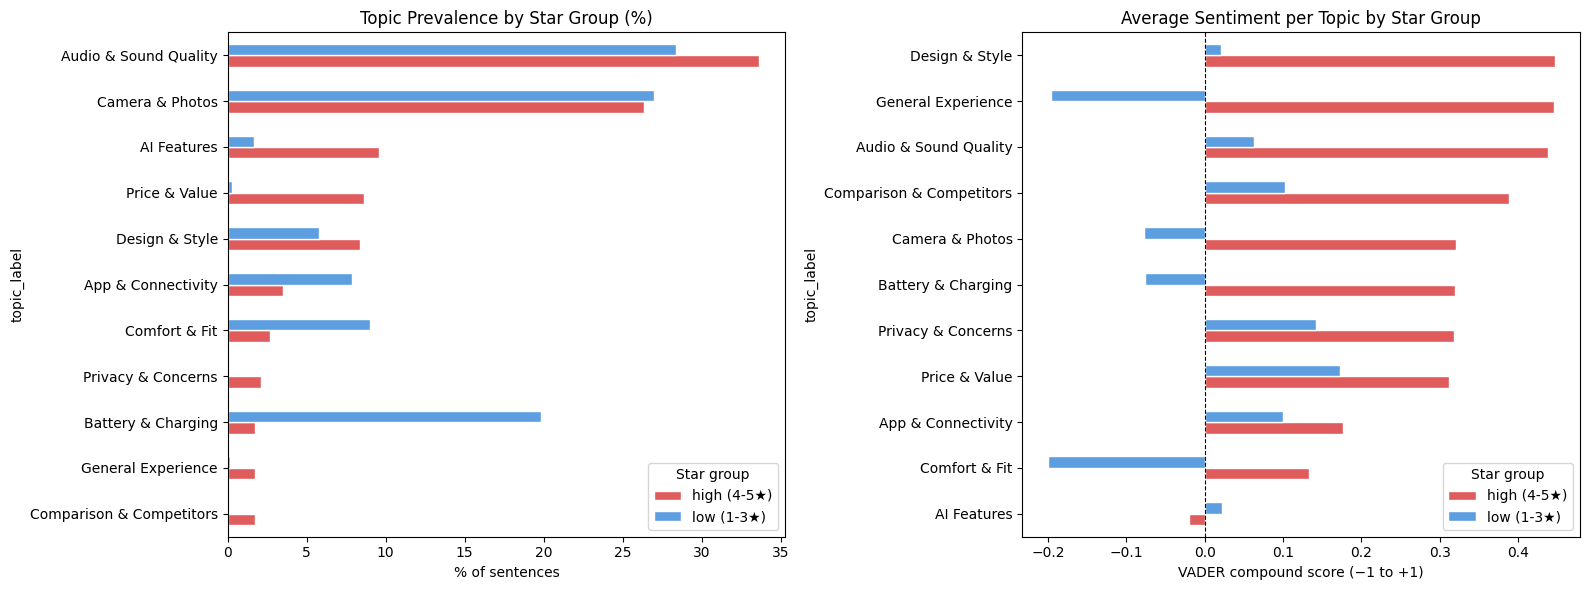

Plot saved to plots/03_topic_sentiment.png

Sentiment by topic and star group:
star_group                high (4-5★)  low (1-3★)
topic_label                                      
AI Features                    -0.020       0.021
App & Connectivity              0.177       0.100
Audio & Sound Quality           0.438       0.063
Battery & Charging              0.320      -0.076
Camera & Photos                 0.321      -0.078
Comfort & Fit                   0.133      -0.201
Comparison & Competitors        0.388       0.103
Design & Style                  0.447       0.020
General Experience              0.445      -0.196
Price & Value                   0.312       0.173
Privacy & Concerns              0.318       0.141


In [25]:
# ── Step 3e: Comparative analysis — low vs high star reviews ──────────────────
# For each topic, compare:
#   1. Prevalence: what share of sentences in low/high reviews belong to this topic?
#   2. Sentiment: what is the average sentiment per topic in each group?

import matplotlib.pyplot as plt

# Exclude outliers from the comparison
sdf_clean = sdf[sdf['topic'] != -1].copy()

# ── Prevalence ────────────────────────────────────────────────────────────────
prevalence = (
    sdf_clean.groupby(['star_group', 'topic_label'])
    .size()
    .reset_index(name='count')
)
prevalence['pct'] = prevalence.groupby('star_group')['count'].transform(lambda x: x / x.sum() * 100)

prev_pivot = prevalence.pivot(index='topic_label', columns='star_group', values='pct').fillna(0)

# ── Sentiment ─────────────────────────────────────────────────────────────────
sent_pivot = (
    sdf_clean.groupby(['star_group', 'topic_label'])['sentiment']
    .mean()
    .unstack('star_group')
    .fillna(0)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

prev_pivot.sort_values('high (4-5★)', ascending=True).plot(
    kind='barh', ax=axes[0], color=['#e05c5c', '#5c9ee0'], edgecolor='white'
)
axes[0].set_title('Topic Prevalence by Star Group (%)')
axes[0].set_xlabel('% of sentences')
axes[0].legend(title='Star group')

sent_pivot.sort_values('high (4-5★)', ascending=True).plot(
    kind='barh', ax=axes[1], color=['#e05c5c', '#5c9ee0'], edgecolor='white'
)
axes[1].set_title('Average Sentiment per Topic by Star Group')
axes[1].set_xlabel('VADER compound score (−1 to +1)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(title='Star group')

plt.tight_layout()
# plt.savefig('plots/03_topic_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/03_topic_sentiment.png')

# Print summary table
print('\nSentiment by topic and star group:')
print(sent_pivot.round(3).to_string())